# 01. EDA and Sequence Structure

**Goal:** Understand the unique data shape required for Sequence Tagging. Unlike standard classification where `X` is a single text string, here `X` is an ordered list of tokens (a sentence), and `y` is an ordered list of tags of the exact same length.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

In [2]:
def load_jsonl(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl('../data/raw/train.jsonl')
test_data = load_jsonl('../data/raw/test.jsonl')
print(f'Train sentences: {len(train_data)}\nTest sentences: {len(test_data)}')

Train sentences: 14041
Test sentences: 3453


## 2. Inspect a Sequence
Notice how every token maps perfectly to a POS (Part of Speech) tag and an NER (Named Entity Recognition) tag.

In [3]:
sample = train_data[0]
for token, pos, ner in zip(sample['tokens'], sample['pos_tags'], sample['ner_tags']):
    print(f'{token:15} {pos:10} {ner}')

EU              NNP        B-ORG
rejects         VBZ        O
German          JJ         B-MISC
call            NN         O
to              TO         O
boycott         VB         O
British         JJ         B-MISC
lamb            NN         O
.               .          O


## 3. Tag Distribution

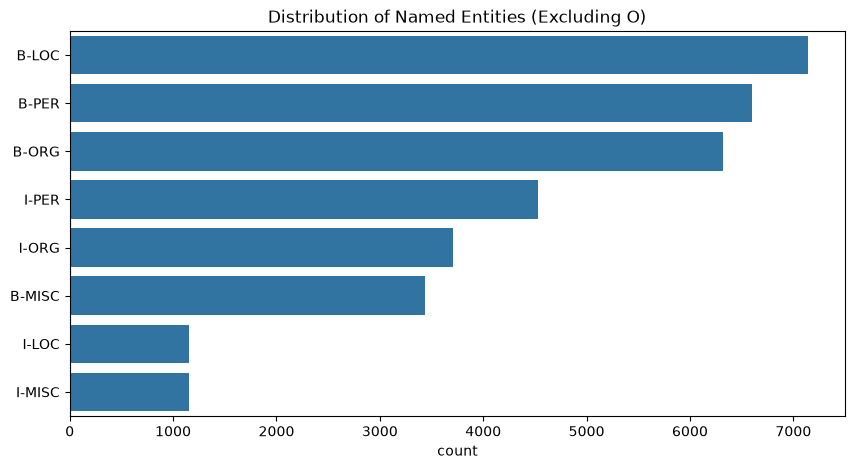

In [4]:
all_ner_tags = [tag for sentence in train_data for tag in sentence['ner_tags'] if tag != 'O']
plt.figure(figsize=(10, 5))
sns.countplot(y=all_ner_tags, order=pd.Series(all_ner_tags).value_counts().index)
plt.title('Distribution of Named Entities (Excluding O)')
plt.show()